In [2]:
import pandas as pd
df=pd.read_csv('student_habits_performance.csv')

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [6]:
df.shape

(1000, 16)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sns.set(style='whitegrid')

In [10]:
df.isna().sum().sum()

np.int64(91)

In [11]:
df.dropna(inplace=True)

In [12]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [20]:
df.describe(include='object').columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='str')

In [24]:
categorical_cols={"gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation"}

In [25]:
categorical_cols

{'diet_quality',
 'extracurricular_participation',
 'gender',
 'internet_quality',
 'parental_education_level',
 'part_time_job'}

In [26]:
for col in categorical_cols:
    print(f"Value counts for {col}: \n{df[col].value_counts()}\n")

Value counts for part_time_job: 
part_time_job
No     713
Yes    196
Name: count, dtype: int64

Value counts for extracurricular_participation: 
extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64

Value counts for parental_education_level: 
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

Value counts for internet_quality: 
internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64

Value counts for gender: 
gender
Male      440
Female    433
Other      36
Name: count, dtype: int64

Value counts for diet_quality: 
diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64



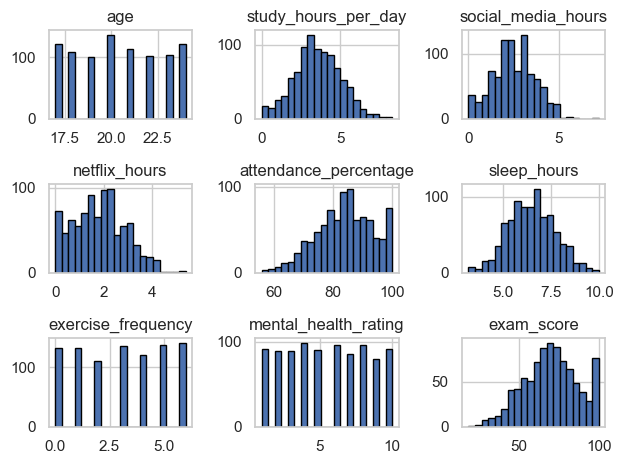

In [28]:
df.hist(bins=20,edgecolor='black')
plt.tight_layout()
plt.show()

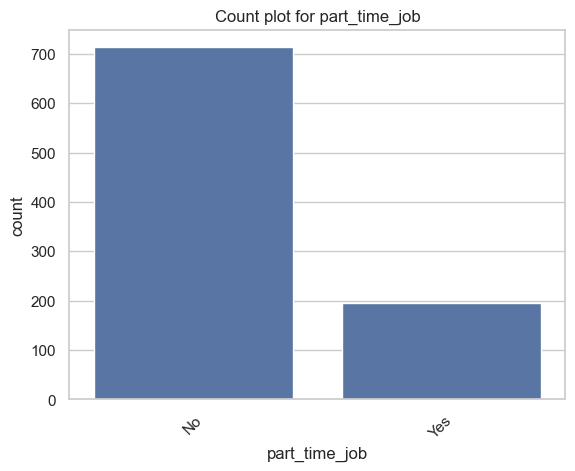

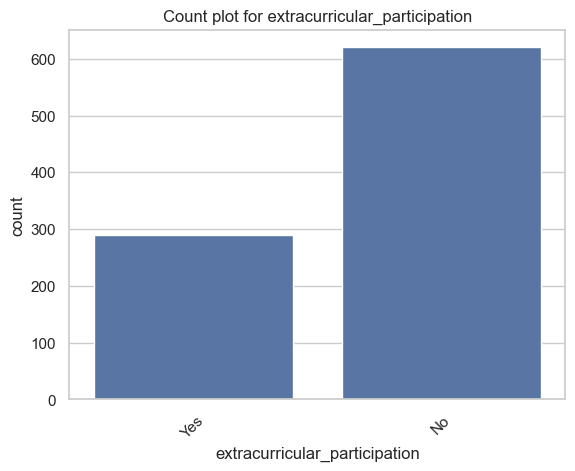

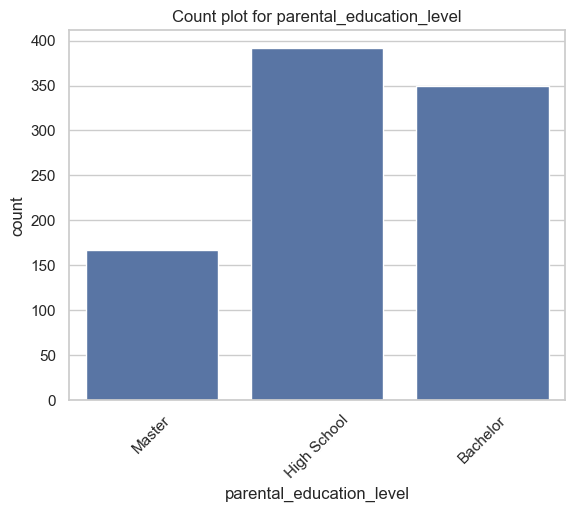

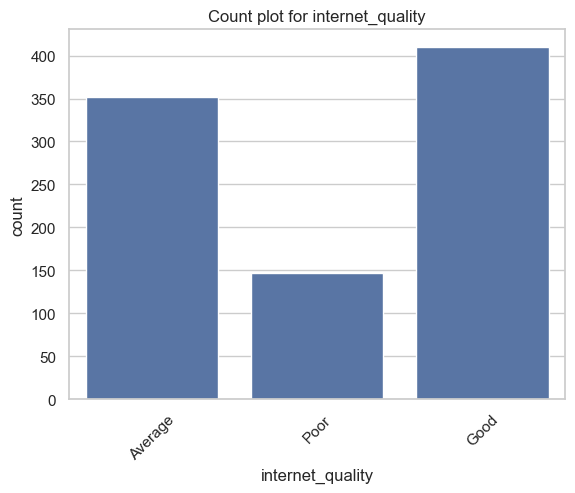

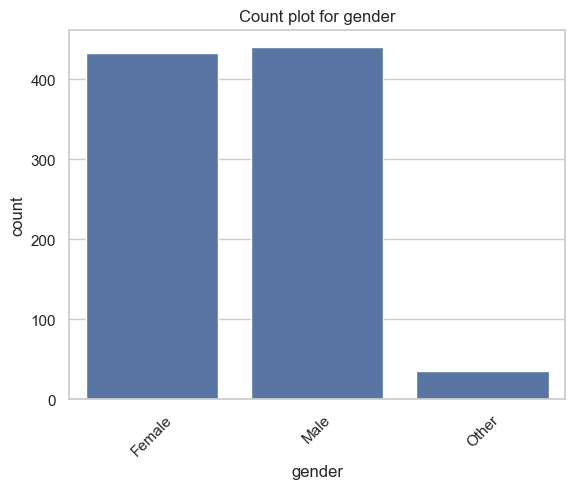

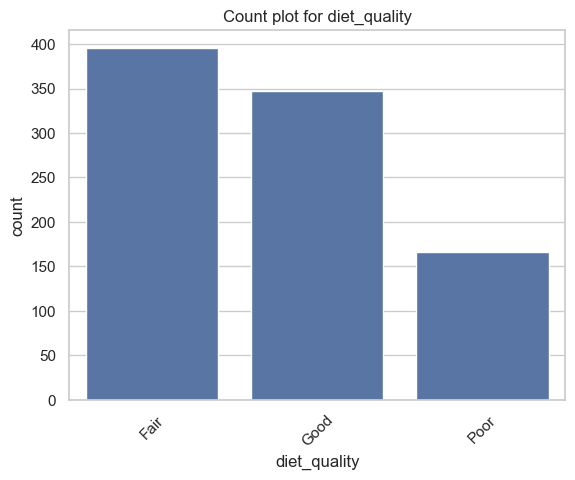

In [29]:
for col in categorical_cols:
    sns.countplot(x=col,data=df)
    plt.title(f"Count plot for {col}")
    plt.xticks(rotation=45)
    plt.show()

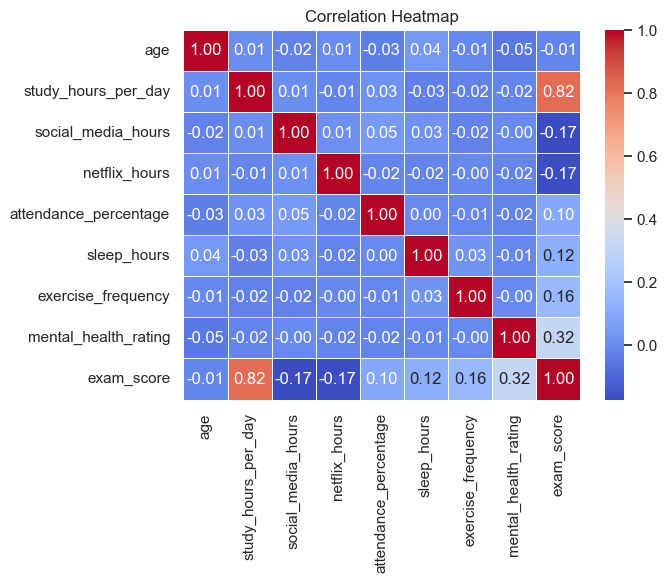

In [31]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [32]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='str')

In [33]:
num_features={'age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'}

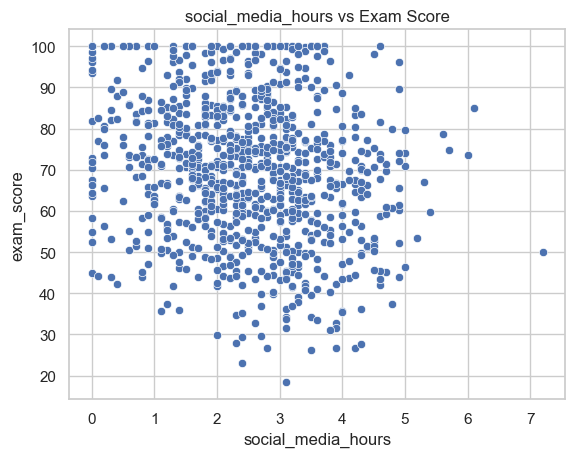

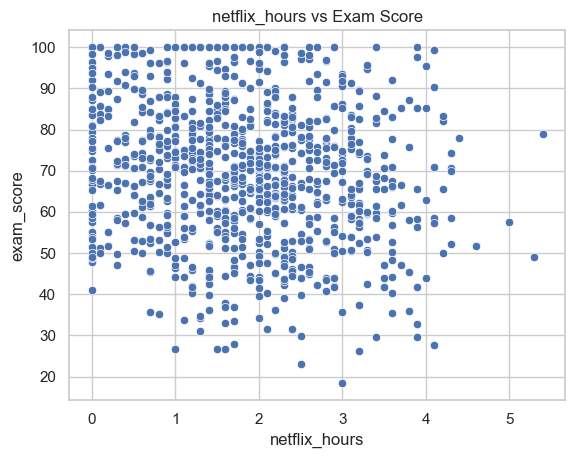

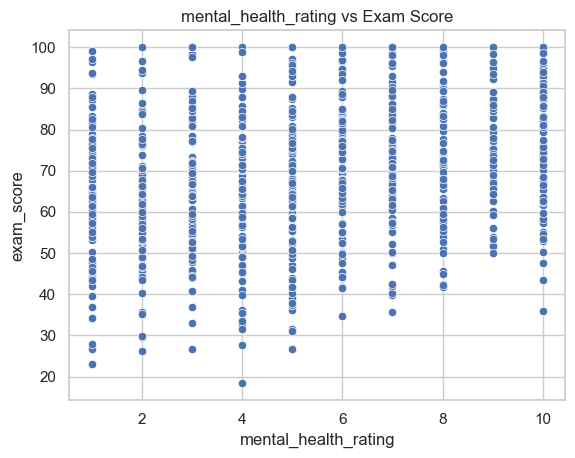

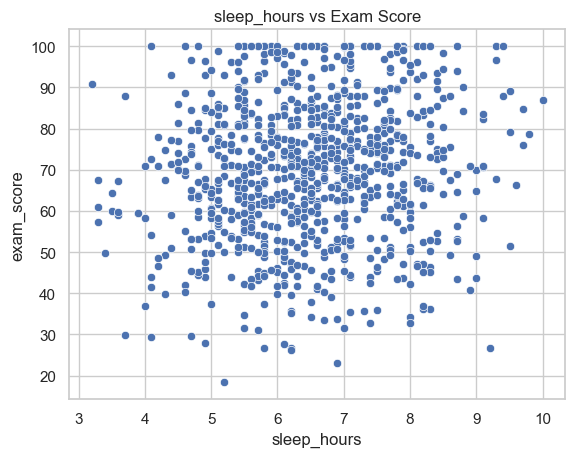

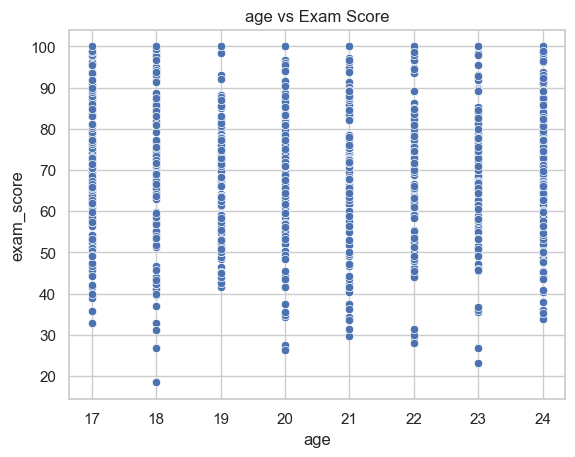

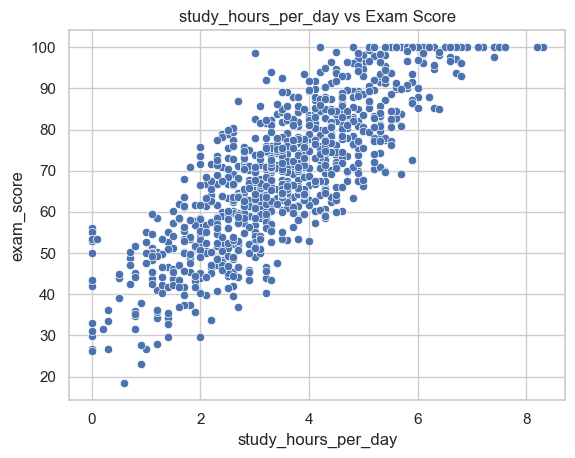

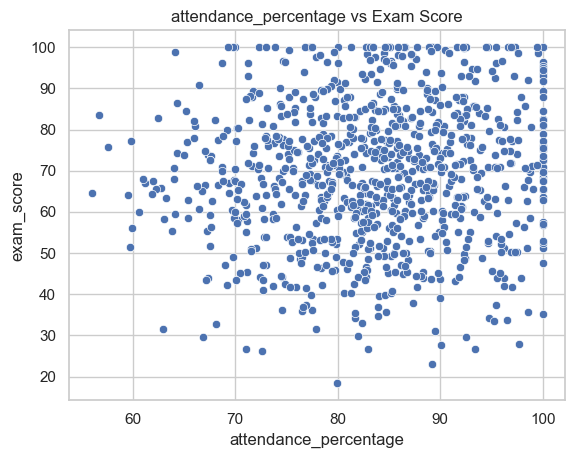

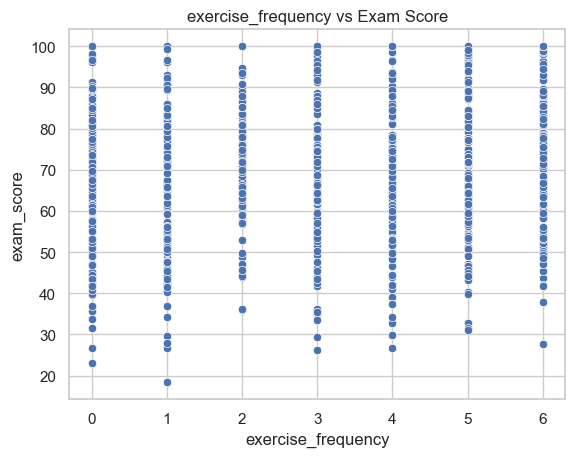

In [34]:
for feature in num_features:
    sns.scatterplot(x=feature, y='exam_score', data=df)
    plt.title(f"{feature} vs Exam Score")
    plt.show()

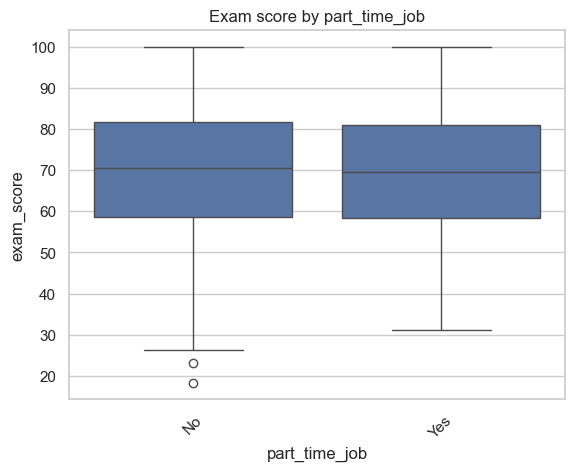

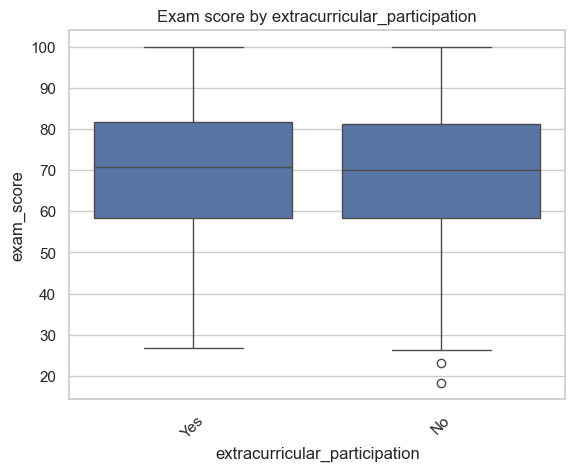

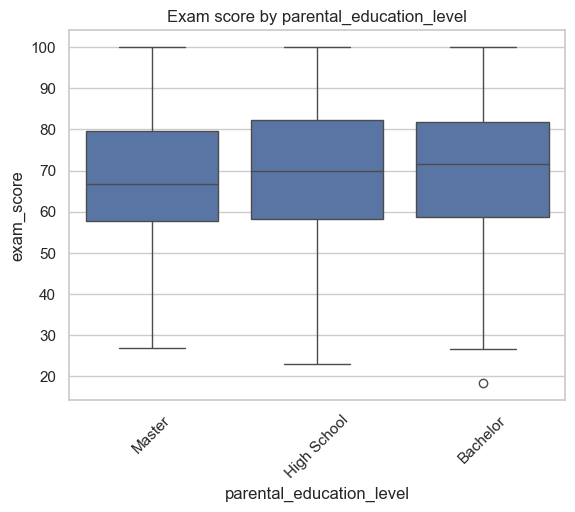

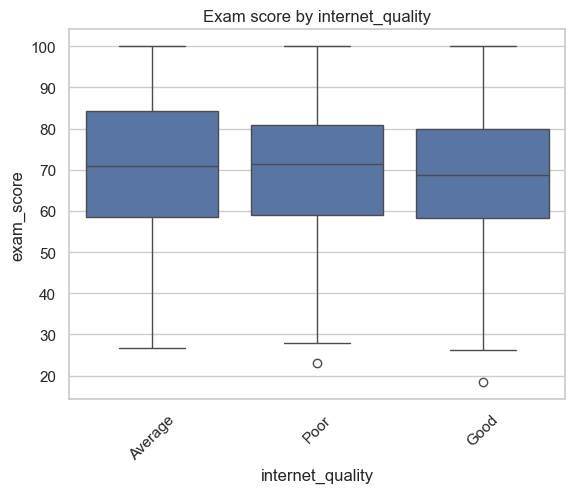

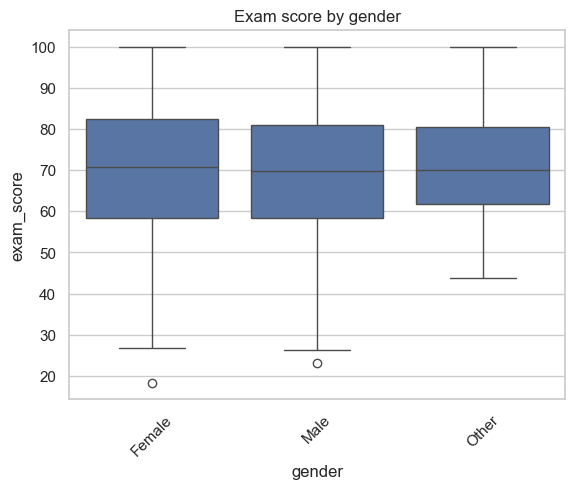

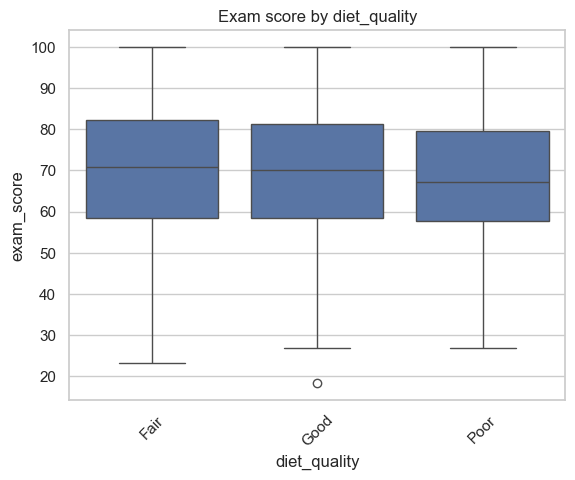

In [36]:
for col in categorical_cols:
    sns.boxplot(x=col, y='exam_score', data=df)
    plt.title(f"Exam score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [38]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

In [39]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [51]:
features=["study_hours_per_day", "attendance_percentage", "sleep_hours", "mental_health_rating","part_time_job"]

In [52]:
features

['study_hours_per_day',
 'attendance_percentage',
 'sleep_hours',
 'mental_health_rating',
 'part_time_job']

In [53]:
target="exam_score"

In [54]:
df_model=df[features+[target]].copy()

In [55]:
df_model

,study_hours_per_day,attendance_percentage,sleep_hours,mental_health_rating,part_time_job,exam_score
0,0.0,85.0,8.0,8,No,56.2
1,6.9,97.3,4.6,8,No,100.0
2,1.4,94.8,8.0,1,No,34.3
3,1.0,71.0,9.2,1,No,26.8
4,5.0,90.9,4.9,1,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,7.5,6,No,76.1
996,2.9,86.0,6.8,6,Yes,65.9
997,3.0,61.9,6.5,9,No,64.4
998,5.4,100.0,7.6,1,Yes,69.7


In [56]:
le=LabelEncoder()

In [58]:
df_model['part_time_job']=le.fit_transform(df_model['part_time_job'])

In [59]:
df_model

,study_hours_per_day,attendance_percentage,sleep_hours,mental_health_rating,part_time_job,exam_score
0,0.0,85.0,8.0,8,0,56.2
1,6.9,97.3,4.6,8,0,100.0
2,1.4,94.8,8.0,1,0,34.3
3,1.0,71.0,9.2,1,0,26.8
4,5.0,90.9,4.9,1,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,7.5,6,0,76.1
996,2.9,86.0,6.8,6,1,65.9
997,3.0,61.9,6.5,9,0,64.4
998,5.4,100.0,7.6,1,1,69.7


In [60]:
X=df_model[features]
y=df_model[target]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [62]:
len(X_train), len(X_test), len(y_train), len(y_test )

(727, 182, 727, 182)

In [63]:
models={
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree": {
        "model":DecisionTreeRegressor(),
        "params": {"max_depth": [3, 5, 10],"min_samples_split": [2, 5]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [50, 100], "max_depth": [5, 10]}
    }
}

In [67]:
best_models=[]

In [68]:
for name,config in models.items():
    print(f"Training {name}...")
    grid=GridSearchCV(config["model"], config["params"], cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)
    y_pred=grid.predict(X_test)
    rmse=np.sqrt(mean_squared_error(y_test, y_pred))
    r2=r2_score(y_test, y_pred)
    
    best_models.append(
        {
            "model": name,
            "best_params": grid.best_params_,
            "rmse": rmse,
            "r2": r2
        }
    )

Training LinearRegression...
Training DecisionTree...
Training RandomForest...


In [69]:
results_df=pd.DataFrame(best_models).sort_values(by='rmse')

In [70]:
results_df

,model,best_params,rmse,r2
0,LinearRegression,{},7.338145,0.831272
2,RandomForest,"{'max_depth': 5, 'n_estimators': 50}",7.754628,0.811575
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.209237,0.788835


In [71]:
import joblib

In [74]:
best_row=results_df.sort_values(by="rmse").iloc[0]

In [75]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.338145
r2                     0.831272
Name: 0, dtype: object

In [76]:
best_model_name=best_row['model']

In [77]:
best_model_name

'LinearRegression'

In [78]:
best_model_config=models[best_model_name]

In [79]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [80]:
final_model=best_model_config['model']

In [81]:
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[9.56,0.14,2.05,1.98,0.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['study_hours_per_day','attendance_percentage','sleep_hours', 'mental_health_rating','part_time_job']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.01073
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [82]:
final_model.predict(X_test)

array([ 74.59529628,  44.56312494,  65.24574029,  71.42430502,
        57.99851846,  60.61304698,  82.25691263,  64.22442454,
        46.42355805,  83.87763264, 109.86076479,  79.75220639,
        76.11212812,  66.85495635,  64.35623557,  87.47666446,
        58.56807717,  55.45149562,  73.73470842,  67.22882072,
        77.42086604,  58.59515015,  84.70133971,  56.4052808 ,
        71.10976502,  58.28779096,  72.47549093,  70.19382401,
        35.38057943,  57.8301418 ,  41.50768325,  74.54938602,
        66.7077738 ,  84.45415703, 100.79359858,  92.71797491,
        60.18318046,  54.27941821,  74.1183648 ,  73.63145597,
        59.33617791,  71.16917324,  70.52672235,  59.41206722,
        81.11484092,  67.28188611,  63.60625277,  42.98530424,
        57.98249864,  63.3153885 ,  69.13935515,  50.42847388,
        52.63399438,  47.10026421,  73.37721953,  78.2264766 ,
        59.04507085,  61.60372745,  66.95712198,  98.05726756,
        68.93258247,  44.07954472,  54.26161987,  77.38

In [83]:
joblib.dump(final_model, 'best_model.pkl')

['best_model.pkl']

In [84]:
joblib.load('best_model.pkl').predict(X_test)

array([ 74.59529628,  44.56312494,  65.24574029,  71.42430502,
        57.99851846,  60.61304698,  82.25691263,  64.22442454,
        46.42355805,  83.87763264, 109.86076479,  79.75220639,
        76.11212812,  66.85495635,  64.35623557,  87.47666446,
        58.56807717,  55.45149562,  73.73470842,  67.22882072,
        77.42086604,  58.59515015,  84.70133971,  56.4052808 ,
        71.10976502,  58.28779096,  72.47549093,  70.19382401,
        35.38057943,  57.8301418 ,  41.50768325,  74.54938602,
        66.7077738 ,  84.45415703, 100.79359858,  92.71797491,
        60.18318046,  54.27941821,  74.1183648 ,  73.63145597,
        59.33617791,  71.16917324,  70.52672235,  59.41206722,
        81.11484092,  67.28188611,  63.60625277,  42.98530424,
        57.98249864,  63.3153885 ,  69.13935515,  50.42847388,
        52.63399438,  47.10026421,  73.37721953,  78.2264766 ,
        59.04507085,  61.60372745,  66.95712198,  98.05726756,
        68.93258247,  44.07954472,  54.26161987,  77.38